# Informe final - Laboratorio 3: reconocimiento de ASL

## 1. Objetivo y alcance

El objetivo fue construir y comparar clasificadores capaces de reconocer las 26
letras del alfabeto ASL y las clases `del`, `nothing` y `space` a partir de
fotografías. La entrega integra el análisis exploratorio, el preprocesamiento,
dos CNN, una red fully-connected, entrenamiento con augmentation, un Random
Forest y pruebas con imágenes no usadas durante el entrenamiento.

## 2. Datos, partición y preprocesamiento

El dataset contiene 87,000 JPEG RGB de 200 x 200 píxeles, organizados en 29
clases balanceadas con 3,000 imágenes por clase. Se trabajó con 600 imágenes por
clase (17,400, equivalentes al 20% del total) para mantener un costo de cómputo
razonable.

La submuestra no se dividió fotografía por fotografía. Primero se agruparon los
nombres consecutivos en bloques de 30 y luego se asignaron bloques completos con
semilla 42:

| Conjunto | Imágenes por clase | Total | Uso |
|---|---:|---:|---|
| Entrenamiento | 420 | 12,180 | Ajuste de parámetros |
| Validación | 90 | 2,610 | Selección de configuración |
| Prueba | 90 | 2,610 | Evaluación final |

El preprocesamiento corrige orientación EXIF, convierte a RGB, reduce a 64 x 64
con interpolación bilineal y normaliza a `[0, 1]` para las redes. No se aplicaron
filtros de desenfoque o enfoque porque pueden borrar o exagerar los espacios
entre dedos que distinguen señas cercanas.

## 3. Modelos neuronales existentes

Se compararon dos CNN y una red fully-connected, con y sin augmentation. El
augmentation usó rotaciones pequeñas, traslación, zoom y cambios leves de brillo
y contraste. No se aplicó flip horizontal: la orientación y lateralidad forman
parte de la seña, por lo que un espejo puede producir una configuración inválida
o cambiar su significado.

| Modelo | Augmentation | Parámetros | Accuracy prueba | F1 macro |
|---|---:|---:|---:|---:|
| CNN2 regularizada | Sí | 97,885 | 84.90% | 84.86% |
| CNN1 baseline | Sí | 1,145,693 | 64.94% | 64.01% |
| CNN2 regularizada | No | 97,885 | 61.34% | 58.64% |
| CNN1 baseline | No | 1,145,693 | 42.38% | 41.24% |
| Fully-connected | Sí | 6,430,749 | 17.55% | 13.81% |
| Fully-connected | No | 6,430,749 | 10.61% | 7.56% |

La CNN2 es mejor que la CNN1 con muchos menos parámetros porque usa
BatchNormalization, Dropout y GlobalAveragePooling2D. La fully-connected pierde
la estructura espacial al aplanar la imagen y por eso necesita más parámetros y
generaliza peor.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Image

RESULTS_DIR = Path('results')
tabla_dl = pd.read_csv(RESULTS_DIR / 'tabla_final.csv')
display(tabla_dl.style.format({
    'acc_val': '{:.2%}', 'acc_test': '{:.2%}', 'f1_macro': '{:.2%}',
    'tiempo_entreno_s': '{:.1f}'
}))

,modelo,aug,params,acc_val,acc_test,f1_macro,tiempo_entreno_s
0,CNN2_aug,True,97885,83.18%,84.90%,84.86%,664.6
1,CNN1_aug,True,1145693,69.35%,64.94%,64.01%,176.6
2,CNN2_regularizada,False,97885,67.89%,61.34%,58.64%,263.5
3,CNN1_baseline,False,1145693,45.02%,42.38%,41.24%,103.4
4,FC_aug,True,6430749,12.72%,17.55%,13.81%,415.5
5,FC,False,6430749,15.79%,10.61%,7.56%,290.9


## 4. Selección y base de Random Forest

### Explicación simple

Se eligió Random Forest porque en proyectos anteriores ha dado buenos resultados
en problemas de clasificación no lineales, es estable, combina muchos árboles
para reducir la dependencia de una sola regla y permite probar configuraciones
sin el costo de entrenar otra red profunda. También proporciona una comparación
útil entre un algoritmo clásico y las CNN.

### Explicación técnica

Un árbol no conoce por sí mismo la geometría de una imagen. Usar los 12,288
píxeles RGB como variables independientes sería pesado y no expresaría de forma
directa la orientación de los dedos. Por eso se construyeron 2,004 características:

- HOG con 9 orientaciones, celdas de 8 x 8 y bloques de 2 x 2, para resumir bordes
  y direcciones locales.
- Promedios de color por región, para conservar información espacial gruesa.
- Histogramas RGB, para representar la distribución global de color e iluminación.

Se probaron cuatro configuraciones y se escogió la mejor por accuracy de
validación, usando F1 macro como criterio secundario:

| Configuración | Árboles | Profundidad | Variables por corte | Hoja mínima | Accuracy validación | F1 macro validación |
|---|---:|---:|---|---:|---:|---:|
| RF_200_full_sqrt | 200 | Sin límite | sqrt | 1 | 70.61% | 70.04% |
| RF_100_depth20_sqrt | 100 | 20 | sqrt | 1 | 70.31% | 69.71% |
| RF_300_depth30_sqrt | 300 | 30 | sqrt | 1 | 69.85% | 69.07% |
| RF_300_full_log2_leaf2 | 300 | Sin límite | log2 | 2 | 67.39% | 66.55% |

Todos alcanzaron 100% en entrenamiento, pero aproximadamente 67-71% en
validación. Esto muestra sobreajuste: los árboles pueden memorizar la submuestra,
aunque el ensamble conserva parte de la capacidad de generalización. Aumentar el
número de árboles más allá de 200 no corrigió ese problema.

In [2]:
candidatos_rf = pd.read_csv(RESULTS_DIR / 'rf_candidates.csv')
display(candidatos_rf.style.format({
    'accuracy_train': '{:.2%}', 'accuracy_val': '{:.2%}',
    'f1_macro_val': '{:.2%}', 'tiempo_entreno_s': '{:.2f}'
}))

,candidate,n_estimators,max_depth,max_features,min_samples_leaf,accuracy_train,accuracy_val,f1_macro_val,tiempo_entreno_s
0,RF_200_full_sqrt,200,nan,sqrt,1,100.00%,70.61%,70.04%,49.39
1,RF_100_depth20_sqrt,100,20.000000,sqrt,1,100.00%,70.31%,69.71%,24.90
2,RF_300_depth30_sqrt,300,30.000000,sqrt,1,100.00%,69.85%,69.07%,72.74
3,RF_300_full_log2_leaf2,300,nan,log2,2,100.00%,67.39%,66.55%,17.92


## 5. Comparación final en la misma prueba

| Modelo | Accuracy prueba | F1 macro prueba |
|---|---:|---:|
| CNN2 con augmentation | 84.90% | 84.86% |
| Random Forest HOG + color | 65.94% | 64.96% |
| CNN2 sin augmentation | 61.34% | 58.64% |

Random Forest superó a la mejor CNN sin augmentation por 4.60 puntos
porcentuales de accuracy. Sin embargo, la CNN con augmentation superó a Random
Forest por 18.97 puntos. El resultado sugiere que las características HOG/color
son una base clásica razonable, pero la CNN aprende representaciones espaciales
más útiles cuando ve variaciones realistas durante el entrenamiento.

La matriz de confusión muestra que Random Forest no reconoció correctamente
ninguna imagen de T y solo alcanzó 4.44% de recall en B y D. En E llegó a 31.11%.
Estos errores explican por qué su F1 macro queda por debajo de su accuracy y
confirman que los contornos HOG no separan bien todas las configuraciones de mano.

,modelo,familia,augmentation,accuracy_test_recalculada,f1_macro_test_recalculado
0,CNN2_aug,CNN,True,84.90%,84.86%
1,RandomForest_HOG_color,Random Forest,False,65.94%,64.96%
2,CNN2_regularizada,CNN,False,61.34%,58.64%


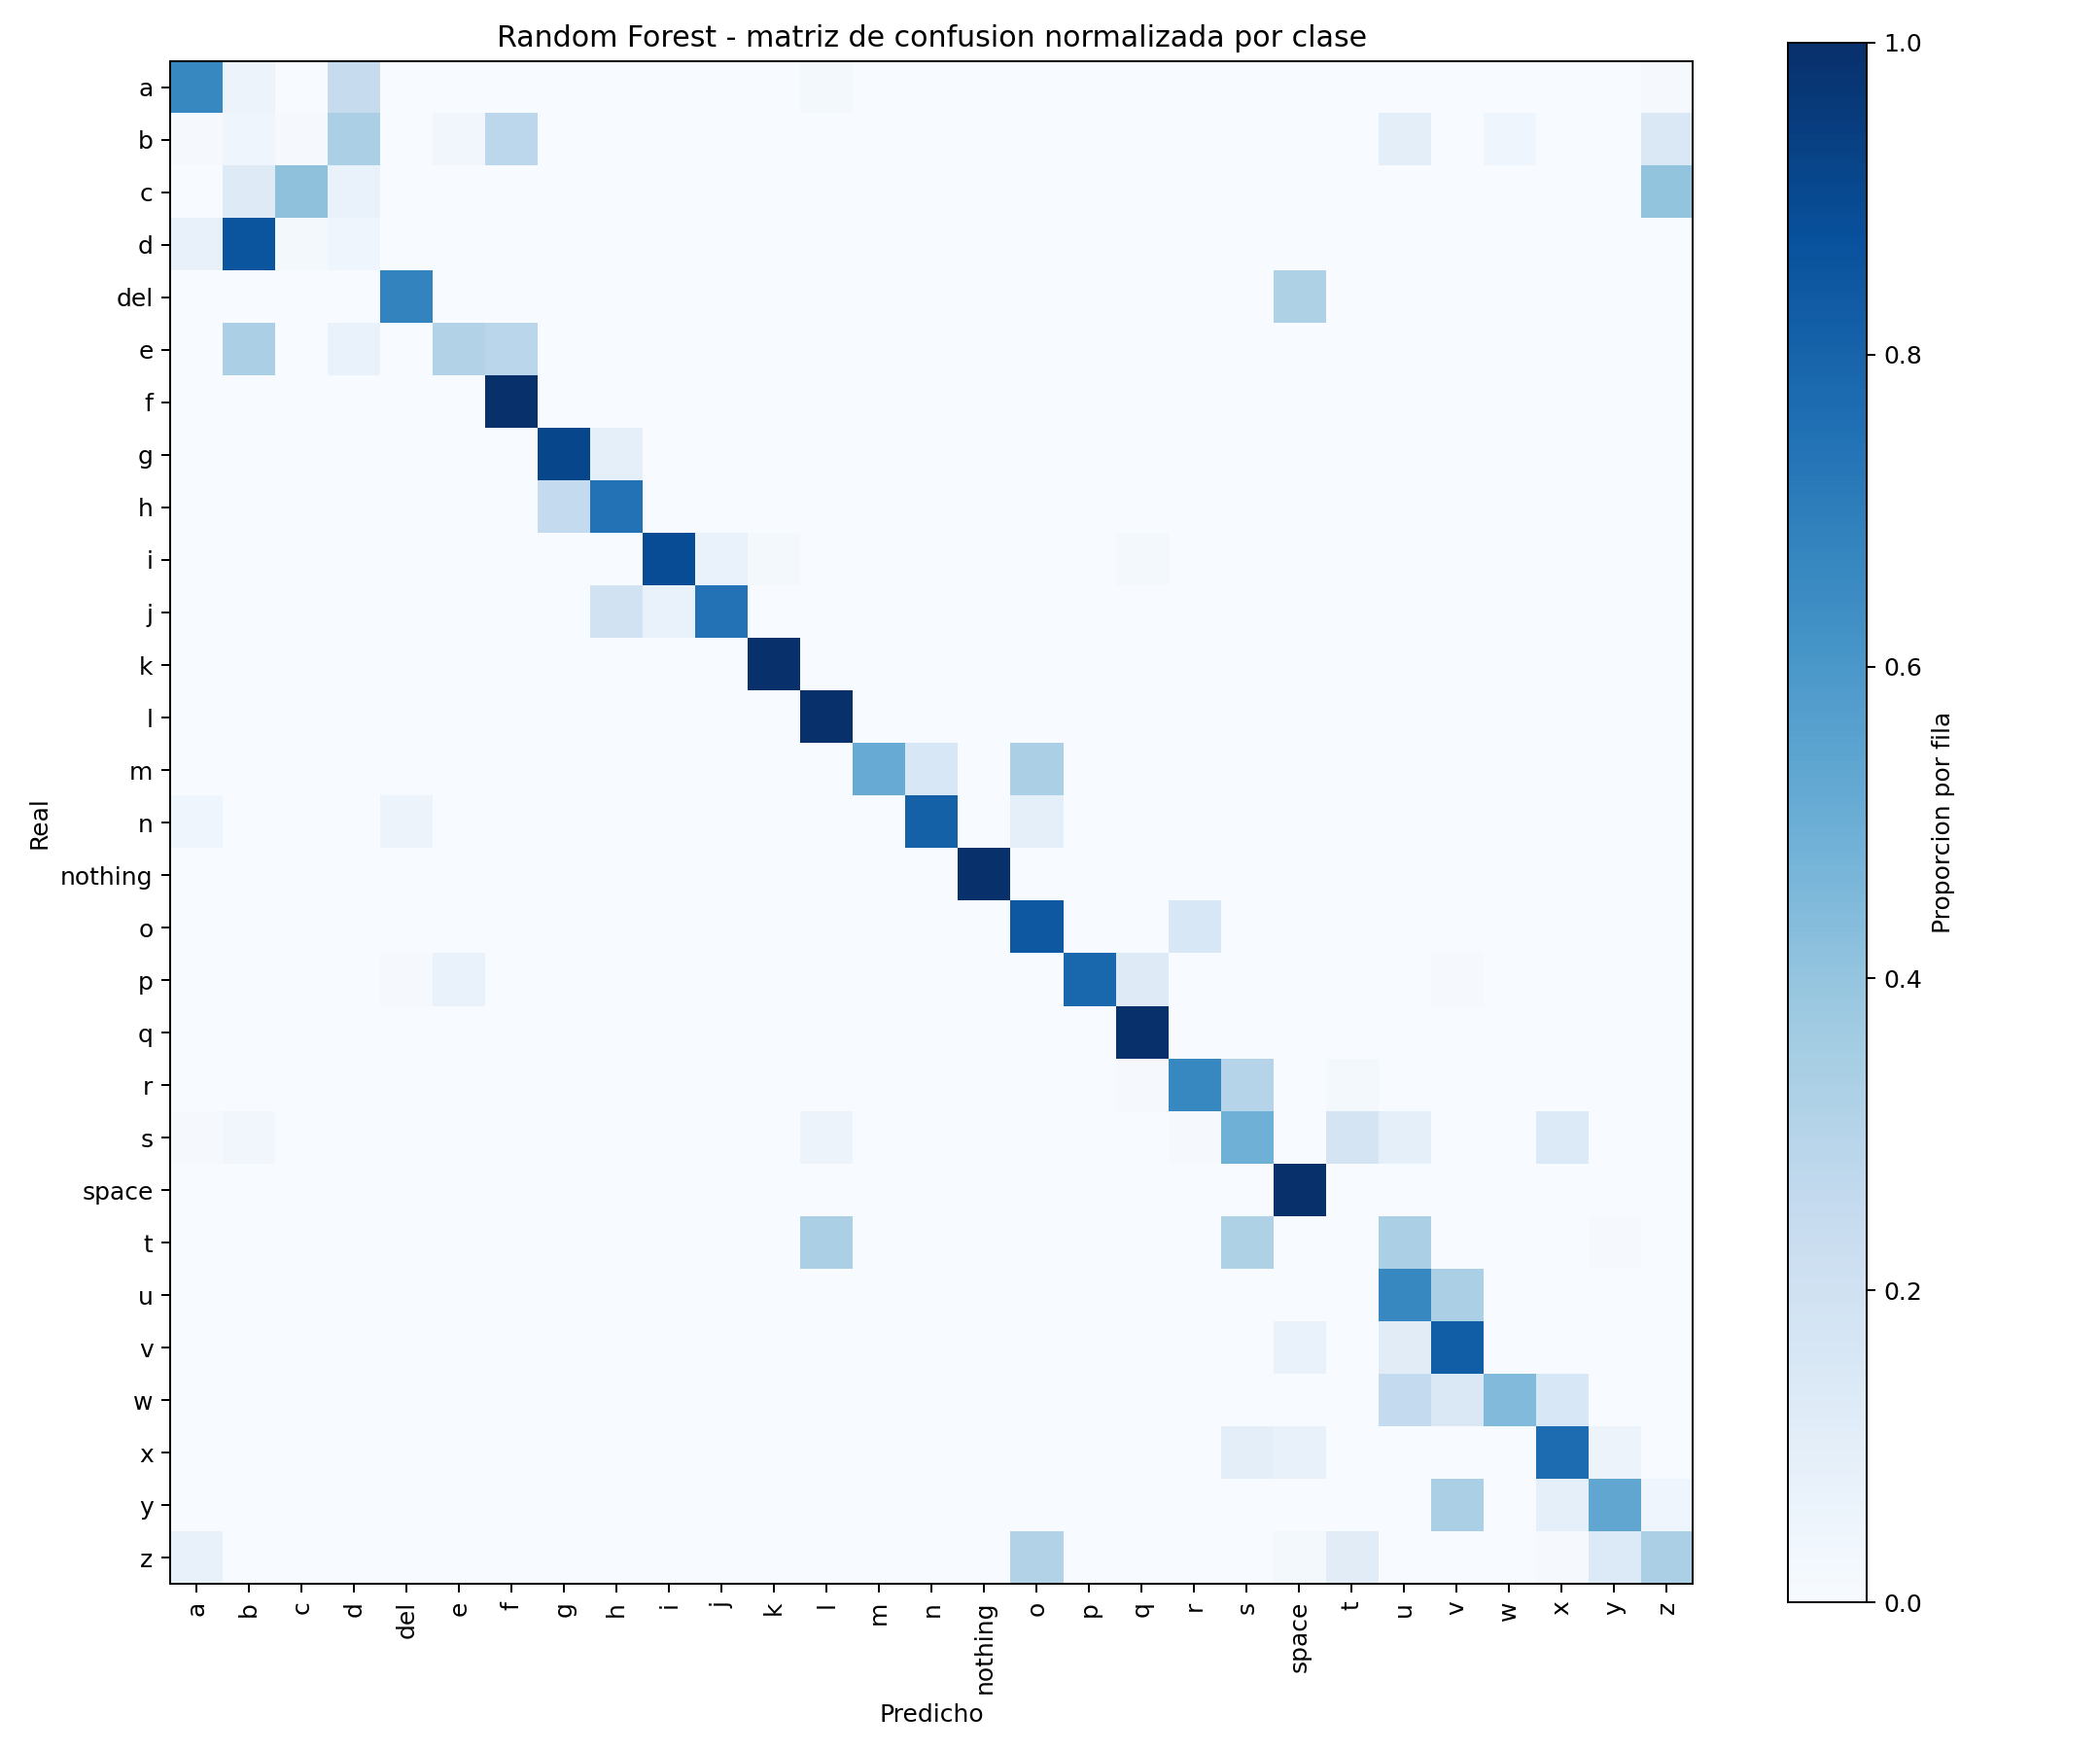

In [3]:
comparacion = pd.read_csv(RESULTS_DIR / 'comparacion_principal.csv')
display(comparacion.style.format({
    'accuracy_test_recalculada': '{:.2%}',
    'f1_macro_test_recalculado': '{:.2%}'
}))
display(Image(filename=str(RESULTS_DIR / 'confusion_matrix_rf.png')))

## 6. Cinco letras A-E

Sobre las 450 imágenes internas de prueba correspondientes a A, B, C, D y E:

| Modelo | Accuracy A-E | F1 macro A-E |
|---|---:|---:|
| CNN2 con augmentation | 84.67% | 88.73% |
| CNN2 sin augmentation | 63.78% | 69.36% |
| Random Forest HOG + color | 29.56% | 37.58% |

También se hizo una comprobación técnica con las cinco imágenes oficiales A-E de
Kaggle. La CNN con augmentation acertó 5/5, la CNN sin augmentation 4/5 y Random
Forest 2/5. Estas cinco imágenes sirven como sanity check, pero no sustituyen las
fotos propias solicitadas por la rúbrica. Tampoco deben interpretarse como una
mejora frente al 29.56% interno de Random Forest: cinco observaciones producen una
estimación demasiado inestable.

In [4]:
comparacion_ae = pd.read_csv(RESULTS_DIR / 'comparacion_A_E_interna.csv')
predicciones_ae = pd.read_csv(RESULTS_DIR / 'predicciones_oficiales_A_E.csv')
display(comparacion_ae.style.format({'accuracy_A_E': '{:.2%}', 'f1_macro_A_E': '{:.2%}'}))
display(predicciones_ae)

,modelo,n_imagenes_A_E,accuracy_A_E,f1_macro_A_E
0,CNN2_aug,450,84.67%,88.73%
1,CNN2_regularizada,450,63.78%,69.36%
2,RandomForest_HOG_color,450,29.56%,37.58%


,archivo,etiqueta_esperada,CNN2_normal_pred,CNN2_normal_confianza,CNN2_aug_pred,CNN2_aug_confianza,RandomForest_pred,RandomForest_confianza,CNN2_normal_correcto,CNN2_aug_correcto,RandomForest_correcto
0,A_test.jpg,a,a,0.632532,a,0.973068,b,0.215,True,True,False
1,B_test.jpg,b,b,0.490649,b,0.920882,a,0.205,True,True,False
2,C_test.jpg,c,c,0.997916,c,0.999999,c,0.535,True,True,True
3,D_test.jpg,d,d,0.951514,d,0.999683,c,0.225,True,True,False
4,E_test.jpg,e,a,0.589336,e,0.947085,e,0.340,False,True,True


## 7. Fotos propias de todos los integrantes

La prueba externa quedó formada por **150 fotografías propias de 15 letras**. Los
tres integrantes aportaron exactamente 50 imágenes y cinco letras distintas, por
lo que se cumple el mínimo solicitado de forma equilibrada:

| Identificador | Letras aportadas | Fotos | Letras distintas |
|---|---|---:|---:|
| Ricardo  | I, J, K, L, R | 50 | 5 |
| Sebastian | M, N, S, U, X | 50 | 5 |
| Vianka  | O, V, W, Y, Z | 50 | 5 |

Los identificadores A/B/C se usan para documentar el aporte sin inventar nombres;
pueden reemplazarse por los nombres reales antes de entregar. Todos los bloques
cumplen la misma cantidad de letras y fotografías.

### Resultado global en las 150 fotos

| Modelo | Correctas | Accuracy | Confianza media |
|---|---:|---:|---:|
| CNN2 con augmentation | 54/150 | 36% | 64.70% |
| CNN2 sin augmentation | 9/150 | 6% | 60.22% |
| Random Forest HOG + color | 0/150 | 0% | 18.55% |

### Resultado de CNN2 con augmentation por integrante

| Identificador | Correctas | Accuracy | Confianza media |
|---|---:|---:|---:|
| Ricardo  | 35/50 | 70% | 75.98% |
| Sebastian | 9/50 | 18% | 60.46% |
| Vianka  | 10/50 | 20% | 57.66% |

Por letra, la CNN con augmentation obtuvo I 50%, J 100%, K 100%, L 90%, R 10%,
M 70%, N 0%, S 0%, U 20%, X 0%, O 0%, V 0%, W 10%, Y 20% y Z 70%. Entre las
confusiones más claras estuvieron N -> M, R -> K, S -> M/E y varias letras del
tercer bloque hacia C/E/Z.

Las tres contribuciones incorporan personas y condiciones de captura distintas; por eso son justamente
la prueba que revela si el sistema generaliza. Las fotografías muestran cambios
de tono de piel, fondo, resolución, distancia, encuadre y orientación. La caída de
84.90% interno a 36% externo es evidencia de cambio de dominio y de que el dataset
de entrenamiento no representa suficientemente el uso real.

El augmentation sigue siendo valioso: obtuvo seis veces la exactitud de la CNN
sin augmentation en las fotos propias. Sin embargo, 36% es insuficiente para un
producto de accesibilidad. Random Forest predijo principalmente clases del entorno
de entrenamiento, con confianza baja, y no acertó ninguna foto externa; sus
características HOG/color fueron especialmente sensibles al nuevo dominio.

,modelo,n_fotos,n_letras,accuracy_fotos_propias,confianza_media
0,CNN2_aug,150,15,36.00%,64.70%
1,CNN2_normal,150,15,6.00%,60.22%
2,RandomForest,150,15,0.00%,18.55%


,integrante,modelo,n_fotos,n_letras,letras,accuracy,confianza_media
0,Integrante A,CNN2_aug,50,5,"I, J, K, L, R",70.00%,75.98%
1,Integrante A,CNN2_normal,50,5,"I, J, K, L, R",2.00%,68.69%
2,Integrante A,RandomForest,50,5,"I, J, K, L, R",0.00%,17.00%
3,Integrante B,CNN2_aug,50,5,"M, N, S, U, X",18.00%,60.46%
4,Integrante B,CNN2_normal,50,5,"M, N, S, U, X",16.00%,52.53%
5,Integrante B,RandomForest,50,5,"M, N, S, U, X",0.00%,18.44%
6,Integrante C,CNN2_aug,50,5,"O, V, W, Y, Z",20.00%,57.66%
7,Integrante C,CNN2_normal,50,5,"O, V, W, Y, Z",0.00%,59.44%
8,Integrante C,RandomForest,50,5,"O, V, W, Y, Z",0.00%,20.21%


modelo,CNN2_aug,CNN2_normal,RandomForest
letra,,,
i,50%,0%,0%
j,100%,10%,0%
k,100%,0%,0%
l,90%,0%,0%
m,70%,0%,0%
n,0%,80%,0%
o,0%,0%,0%
r,10%,0%,0%
s,0%,0%,0%


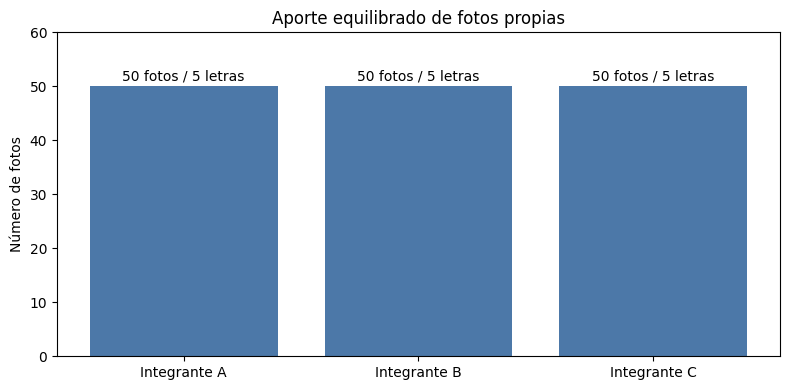

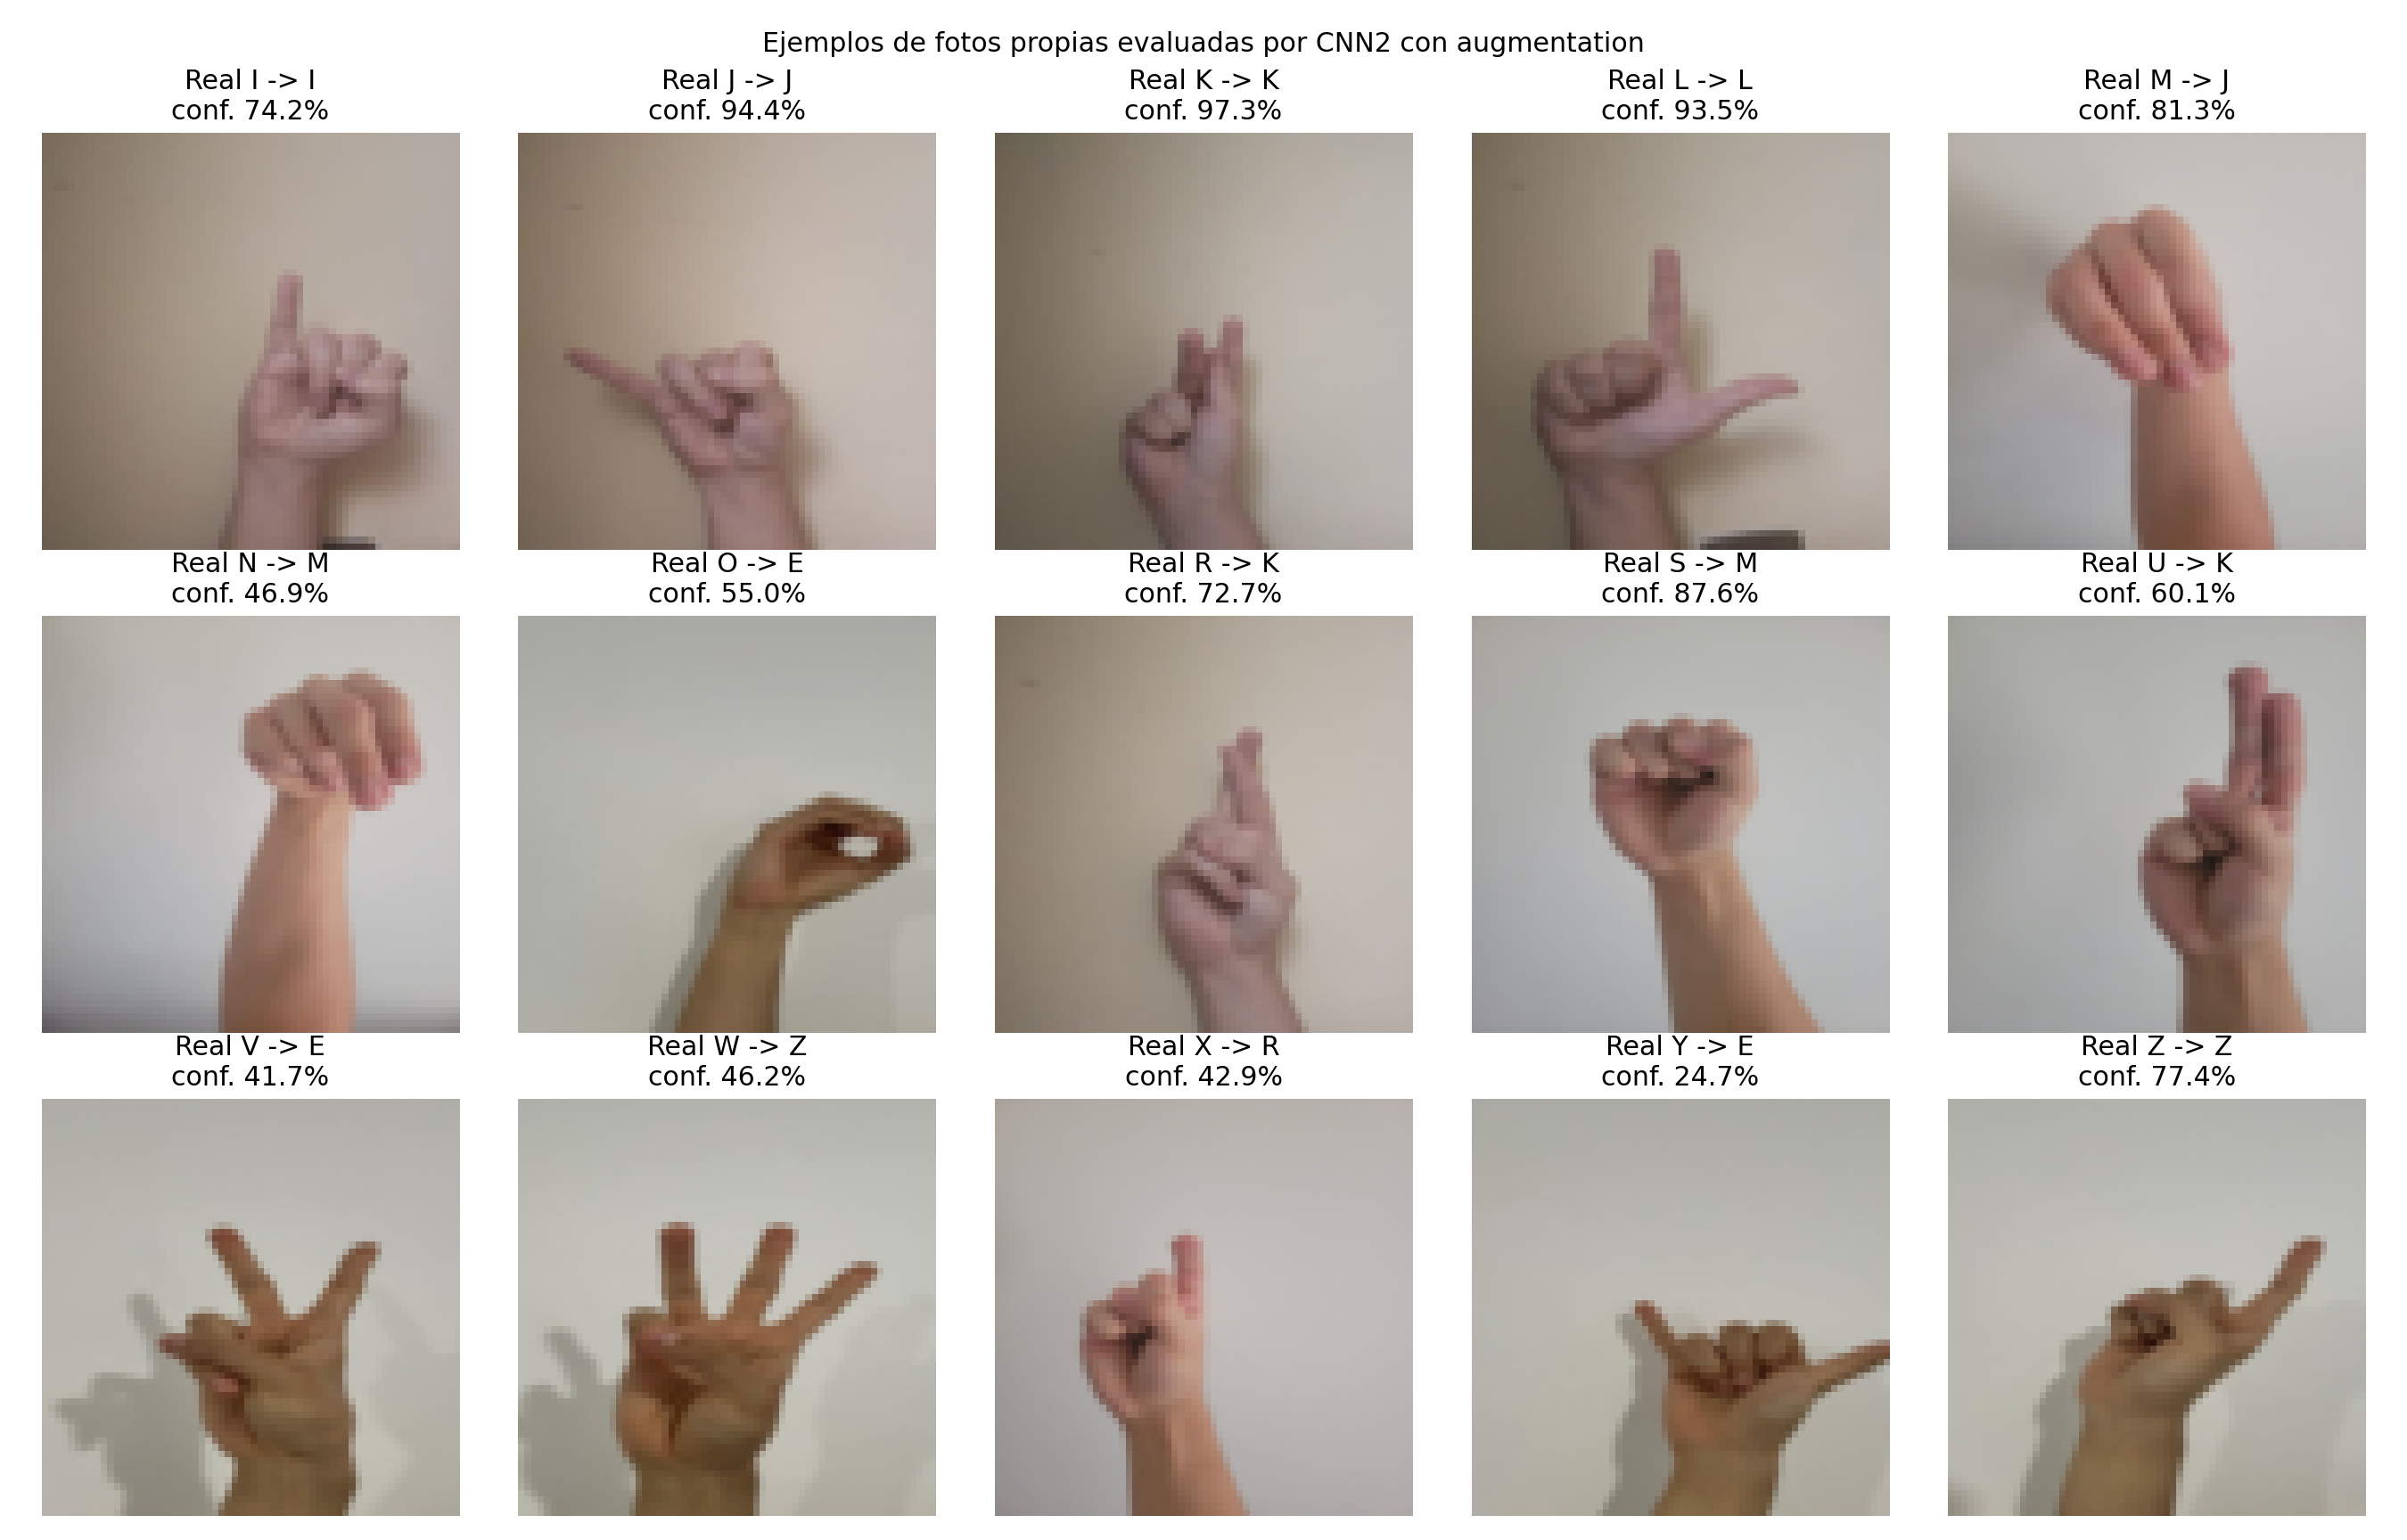

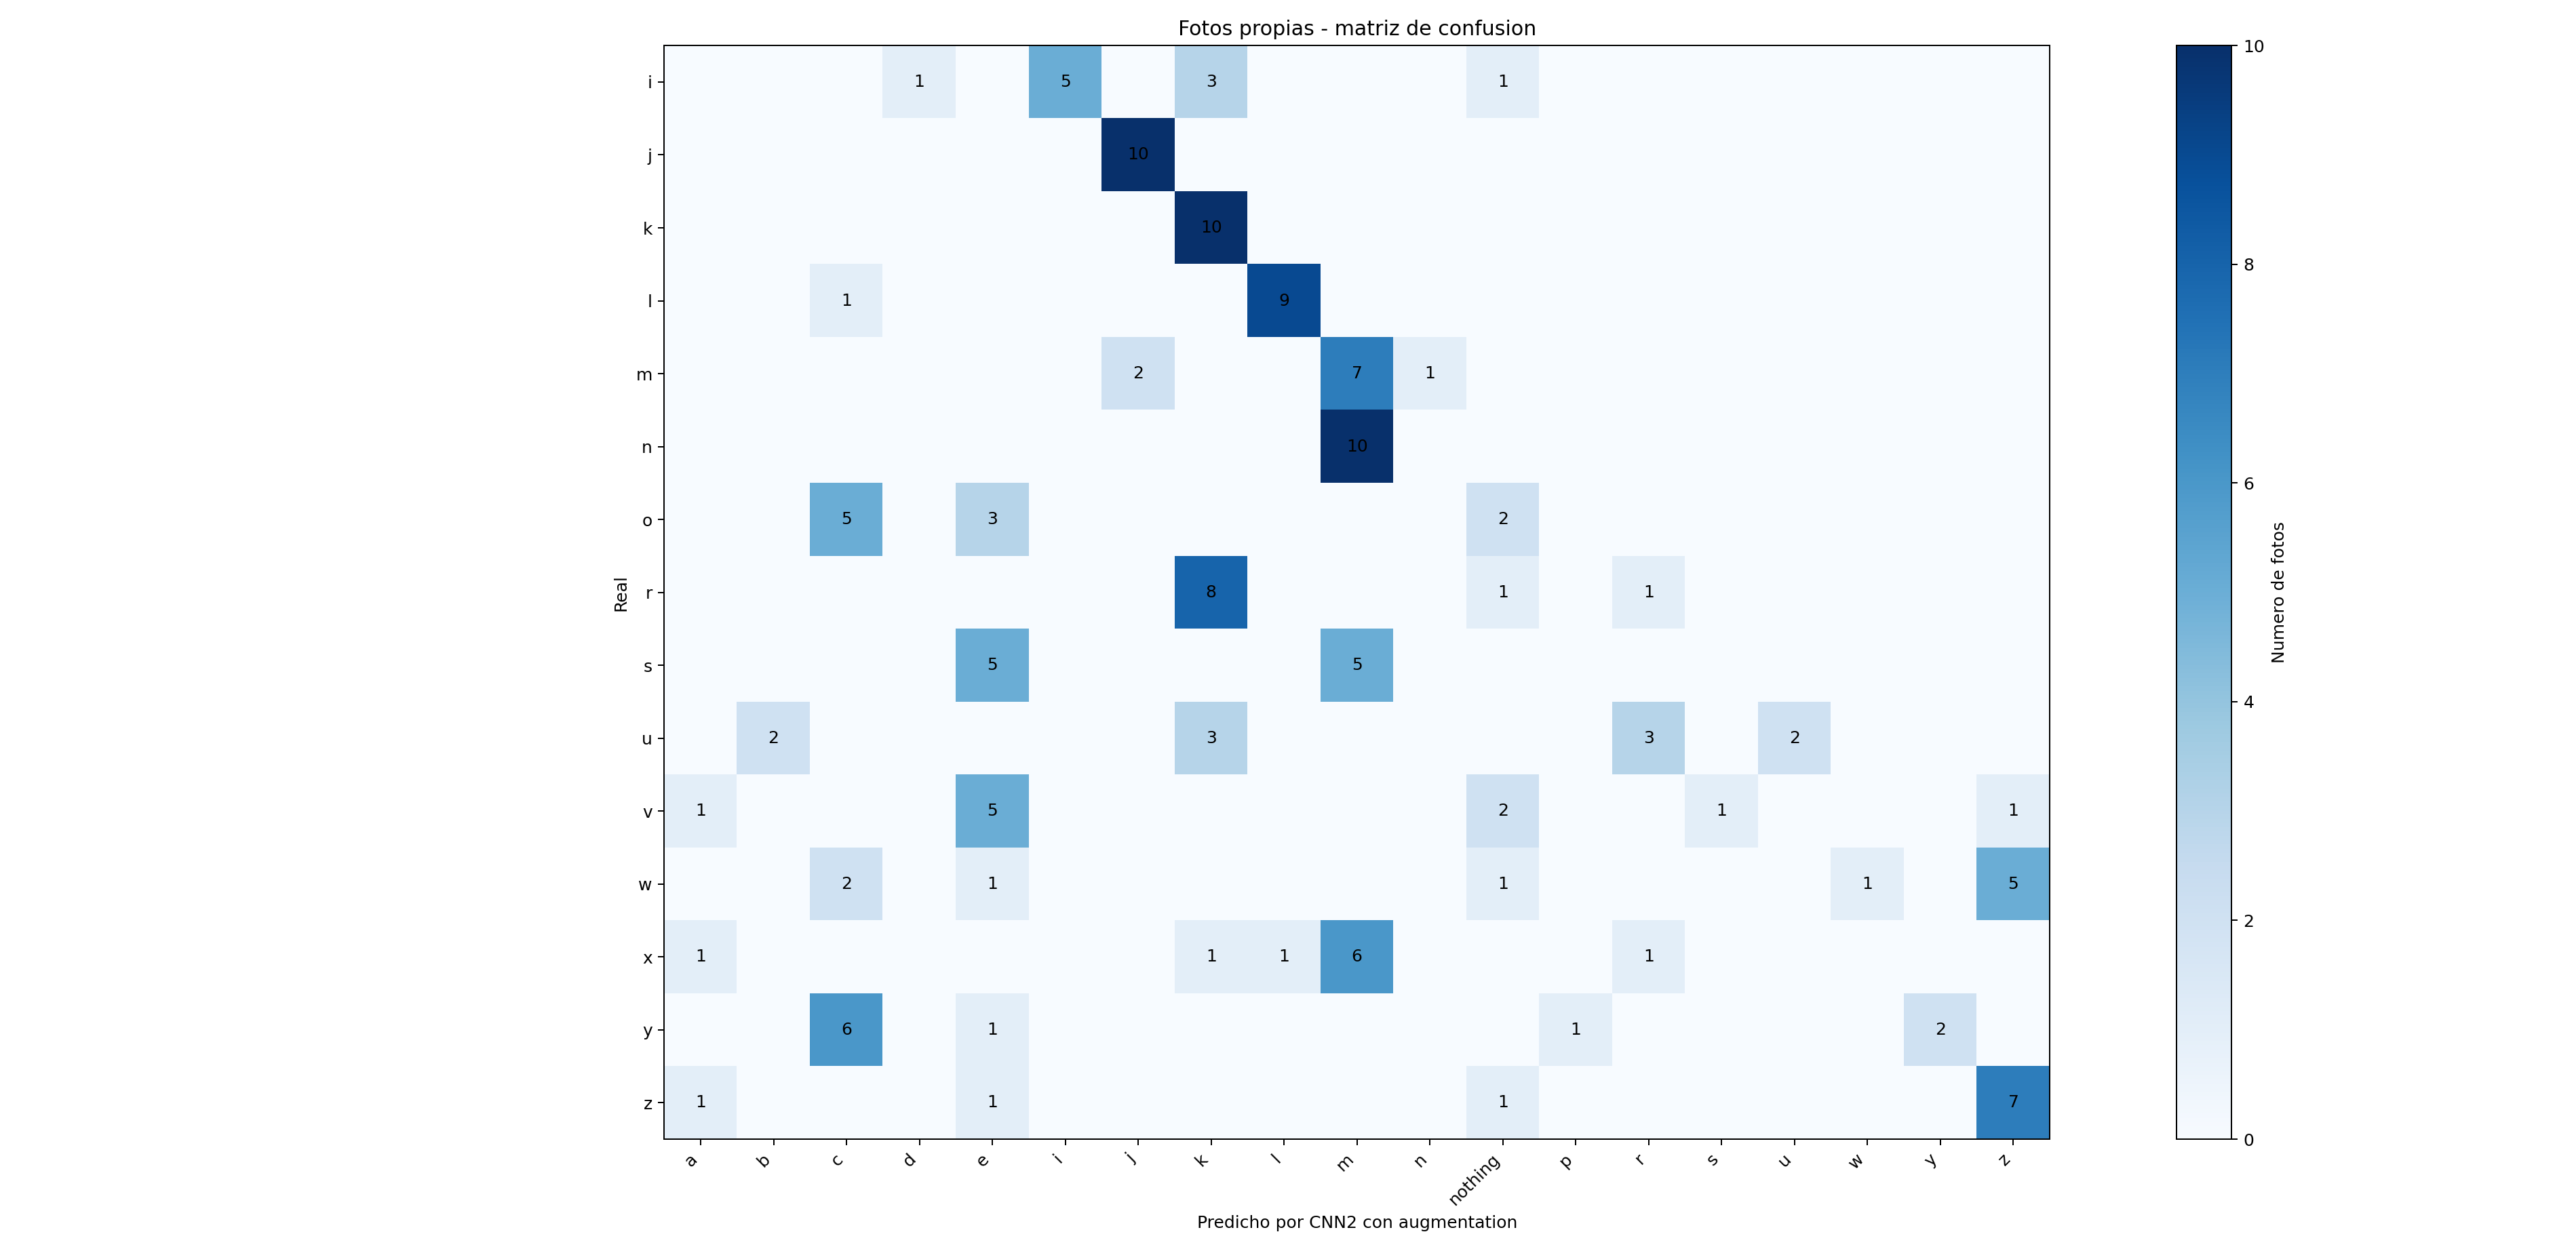

In [5]:
resumen_propias = pd.read_csv(RESULTS_DIR / 'comparacion_fotos_propias.csv')
por_letra = pd.read_csv(RESULTS_DIR / 'fotos_propias_por_letra.csv')
por_integrante = pd.read_csv(RESULTS_DIR / 'comparacion_fotos_propias_por_integrante.csv')
display(resumen_propias.style.format({
    'accuracy_fotos_propias': '{:.2%}', 'confianza_media': '{:.2%}'
}))
display(por_integrante.style.format({'accuracy': '{:.2%}', 'confianza_media': '{:.2%}'}))
display(por_letra.pivot(index='letra', columns='modelo', values='recall').style.format('{:.0%}'))

import matplotlib.pyplot as plt
aporte = por_integrante[por_integrante['modelo'] == 'CNN2_aug']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(aporte['integrante'], aporte['n_fotos'], color='#4C78A8')
ax.set(title='Aporte equilibrado de fotos propias', ylabel='Número de fotos', ylim=(0, 60))
for bar, letras in zip(bars, aporte['n_letras']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{int(bar.get_height())} fotos / {int(letras)} letras', ha='center')
plt.tight_layout()
plt.show()

display(Image(filename=str(RESULTS_DIR / 'ejemplos_fotos_propias.png')))
display(Image(filename=str(RESULTS_DIR / 'confusion_fotos_propias_cnn_aug.png')))

## 8. Accesibilidad y sesgo

El dataset no documenta de forma suficiente tono de piel, edad, tamaño de mano,
discapacidad motora, mano dominante o identidad de la persona. Muchas imágenes
comparten fondo y condiciones de captura, por lo que un modelo puede aprender
atajos visuales. La división por bloques reduce la fuga entre fotografías
consecutivas, pero no garantiza una separación real por persona porque no existen
identificadores de sujeto.

Además, J y Z son señas dinámicas en ASL; una fotografía estática no representa
su trayectoria. Un clasificador de una sola imagen puede acertar una pose del
dataset sin resolver el problema real de reconocimiento temporal.

Para acercar el prototipo a un uso real se recomienda:

1. Recolectar datos con consentimiento de muchas personas y condiciones de cámara,
   fondo, distancia e iluminación variadas.
2. Separar entrenamiento y prueba por persona, no solo por archivo.
3. Reportar métricas por tono de piel, mano dominante, dispositivo y entorno,
   además del promedio global.
4. Usar secuencias de video y un modelo temporal para J, Z y señas continuas.
5. Incorporar calibración y una opción de "no estoy seguro" en vez de forzar una
   letra cuando la confianza sea baja.
6. Probar con usuarios de la comunidad sorda y diseñar mecanismos de corrección y
   privacidad antes de desplegar el sistema.

## 9. Conclusión

El mejor modelo es CNN2 con augmentation. Logra la mayor efectividad interna y,
aunque solo obtiene 36% en las 150 fotos propias, alcanza seis veces la exactitud
de la misma CNN sin augmentation. Random Forest es una comparación clásica válida
y supera a la CNN sin augmentation dentro del dataset, pero su fracaso fuera de
él evidencia que HOG/color y los datos actuales no cubren la variación real. La
conclusión principal no es solo que augmentation mejora el accuracy: también
mejora la capacidad de reconocer manos y condiciones distintas. Aun así, se
necesitan datos por persona, evaluación de equidad y modelado temporal para un
producto accesible.

## Reproducción

Desde la raíz del repositorio, ejecute:

```powershell
.\.venv\Scripts\python.exe Lab3\src\prepare_asl_data.py
.\.venv\Scripts\python.exe Lab3\src\random_forest_pipeline.py
```

La segunda orden reutiliza características y modelo si ya existen. Para forzar un entrenamiento nuevo, elimine manualmente los artefactos generados de `Notebooks/data` y `Notebooks/models` después de confirmar que no necesita conservarlos.

In [6]:
archivos_clave = [
    Path('mejor_modelo.keras'),
    Path('mejor_modelo_aug.keras'),
    Path('models/random_forest_hog_color.joblib'),
    RESULTS_DIR / 'metrics_random_forest.json',
    RESULTS_DIR / 'predicciones_fotos_propias.csv',
]
pd.DataFrame({
    'archivo': [str(path) for path in archivos_clave],
    'existe': [path.exists() for path in archivos_clave],
    'tamano_MB': [round(path.stat().st_size / 1024**2, 2) if path.exists() else None for path in archivos_clave],
})

,archivo,existe,tamano_MB
0,mejor_modelo.keras,True,1.18
1,mejor_modelo_aug.keras,True,1.20
2,models\random_forest_hog_color.joblib,True,11.07
3,results\metrics_random_forest.json,True,0.00
4,results\predicciones_fotos_propias.csv,True,0.02
